Double-well params: DoubleWellParams(a=10, b=0, sigma=0.15, dt=0.001, T=10.0)
Wilson–Cowan params: WCParams(wxx=2.0, wxy=3.0, wyx=3.0, wyy=2.0, Ix=0.5, Iy=0.5, tau=0.02, beta=6.0, theta=0.3, sigma=0.1, dt=0.001, T=5.0)


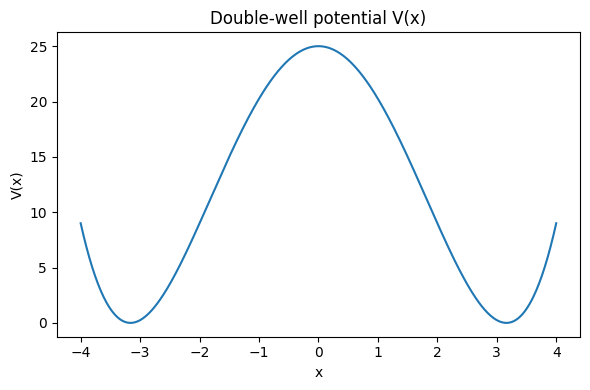

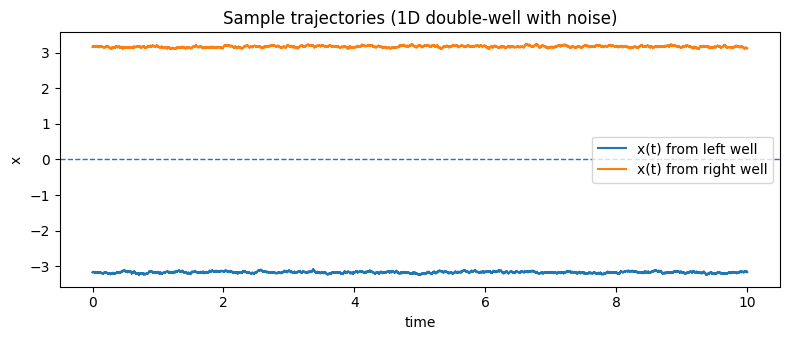

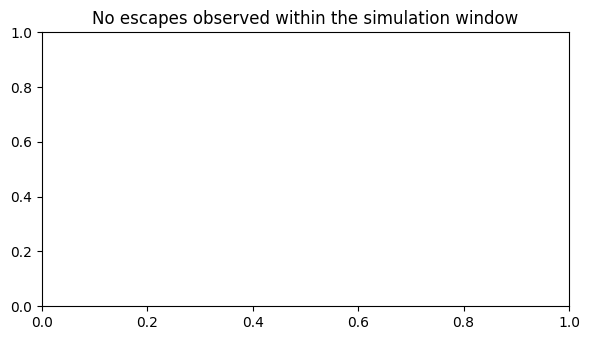


Double-well escape-time summary:
 trials  observed_escapes  mean_escape_time  median_escape_time  min_escape_time  max_escape_time
    100                 0               NaN                 NaN              NaN              NaN


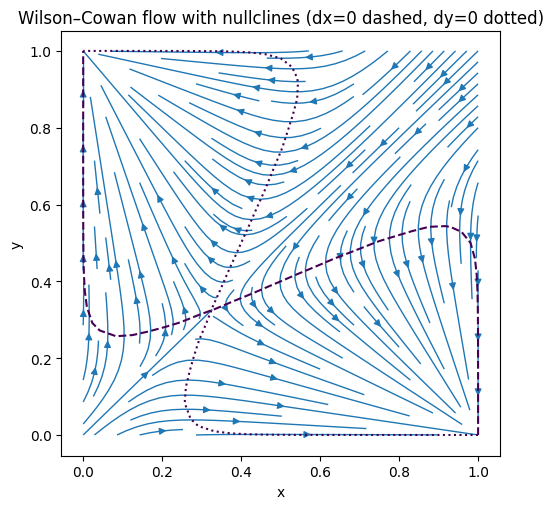

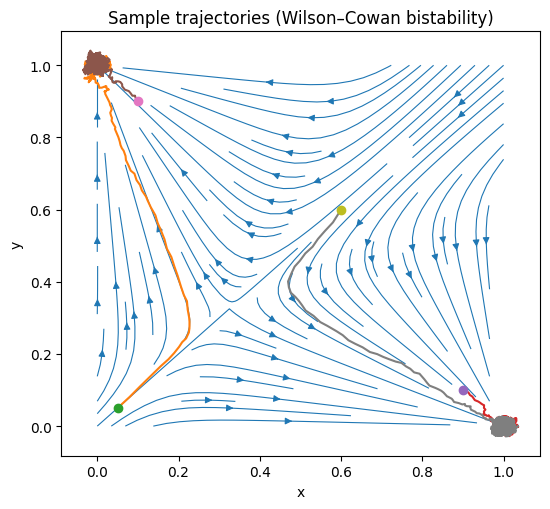


Wilson–Cowan basin fractions:
 n_initial_conditions  basin_fraction_x  basin_fraction_y  ties
                  200              0.47              0.53   0.0


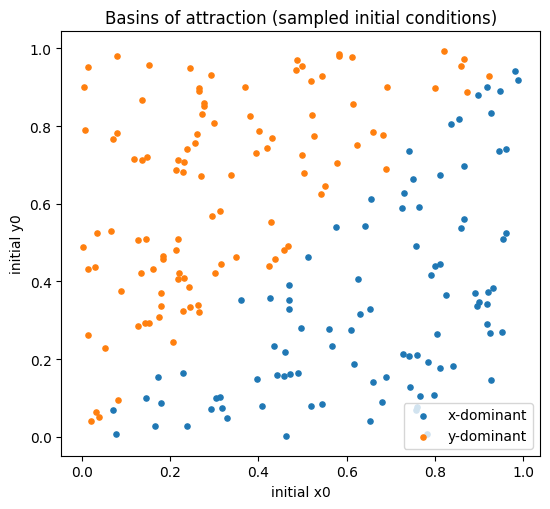


Done. Tweak robustness via:
 - Double-well: a↑ (deeper wells), b (tilt), sigma↓ (less noise).
 - Wilson–Cowan: wxy/wyx↑ (competition), beta↑ (steeper), tau↓ (faster return), sigma↓ (less noise), Ix/Iy (bias).


In [1]:
# -*- coding: utf-8 -*-
"""
Two-attractor toy models: simulations + visualizations

Runs:
1) 1D double-well SDE (Euler–Maruyama):
   - Plots potential V(x)
   - Two sample trajectories (from each well)
   - Escape-time histogram (left → right)
   - Text summary of escape stats

2) 2D Wilson–Cowan-like bistable system:
   - Flow field + nullclines (dx=0 dashed, dy=0 dotted)
   - Sample trajectories from different initial conditions
   - Basin fractions from random initial conditions
   - Scatter of initial conditions colored by final attractor

Notes:
- Uses matplotlib only (no seaborn)
- One chart per figure; no explicit color styling
"""

import math
from dataclasses import dataclass
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ============================
# ======== USER CONFIG ========
# ============================

# --- Double-well parameters (edit here) ---
DW_A = 10       # well separation/depth (↑a → deeper wells & higher barrier → more robust)
DW_B = 0       # tilt (bias >0 favors right, <0 favors left)
DW_SIGMA = 0.15  # noise amplitude (↑sigma → less robust)
DW_DT = 1e-3
DW_T = 10.0

# Escape-time experiment settings
DW_N_TRIALS = 100
DW_ARRIVAL_HALF_WIDTH = 0.2   # window half-width around +sqrt(a) for "arrived" detection

# --- Wilson–Cowan parameters (edit here) ---
WC_WXX = 2.0    # self-excitation for x (↑ strengthens x state's self-hold)
WC_WXY = 3.0    # inhibition from y to x (↑ strengthens competition → more robust WTA)
WC_WYX = 3.0    # inhibition from x to y
WC_WYY = 2.0    # self-excitation for y
WC_IX  = 0.5    # bias input to x (↑ favors x-dominant)
WC_IY  = 0.5    # bias input to y
WC_TAU = 0.02   # time constant (↓ → faster return to fixed point)
WC_BETA = 6.0   # nonlinearity gain (↑ → steeper, easier bistability)
WC_THETA = 0.3  # nonlinearity threshold
WC_SIGMA = 0.1 # noise amplitude
WC_DT = 1e-3
WC_T = 5.0

# Basin sampling
WC_N_IC = 200   # number of random initial conditions
WC_IC_SEED = 123
WC_LOW_NOISE = 1e-6  # noise for basin computation
WC_T_FOR_BASIN = 2.0 # shorter run just to settle to attractor


# ============================
# ====== IMPLEMENTATION ======
# ============================

# ---------- 1) Double-well SDE ----------

@dataclass
class DoubleWellParams:
    a: float
    b: float
    sigma: float
    dt: float
    T: float

def V_double_well(x, a=1.0, b=0.0):
    """Potential: V(x) = 1/4 (x^2 - a)^2 - b x"""
    return 0.25*(x**2 - a)**2 - b*x

def dVdx_double_well(x, a=1.0, b=0.0):
    """Derivative: dV/dx = x(x^2 - a) - b"""
    return x*(x**2 - a) - b

def simulate_double_well(params: DoubleWellParams, x0: float, seed: int = 0):
    rng = np.random.default_rng(seed)
    n = int(params.T/params.dt)
    x = np.empty(n)
    x[0] = x0
    for i in range(1, n):
        x_prev = x[i-1]
        x[i] = x_prev - dVdx_double_well(x_prev, params.a, params.b)*params.dt \
               + params.sigma*np.sqrt(params.dt)*rng.normal()
    t = np.linspace(0.0, params.T, n)
    return t, x

def estimate_escape_time(params: DoubleWellParams, x0: float,
                         target_region: Tuple[float,float],
                         seed: int = 0, tmax: float = None):
    """First passage time to the interval target_region; returns NaN if not reached."""
    rng = np.random.default_rng(seed)
    dt = params.dt
    n = int((tmax if tmax is not None else params.T)/dt)
    x = x0
    for i in range(1, n+1):
        x = x - dVdx_double_well(x, params.a, params.b)*dt + params.sigma*np.sqrt(dt)*rng.normal()
        if target_region[0] <= x <= target_region[1]:
            return i*dt
    return np.nan


# ---------- 2) Wilson–Cowan ----------

@dataclass
class WCParams:
    wxx: float; wxy: float; wyx: float; wyy: float
    Ix: float; Iy: float
    tau: float
    beta: float
    theta: float
    sigma: float
    dt: float
    T: float

def phi(z, beta=4.0, theta=0.0):
    return 1.0/(1.0 + np.exp(-beta*(z - theta)))

def wc_step(x, y, p: WCParams):
    dx = (-x + phi(p.wxx*x - p.wxy*y + p.Ix, p.beta, p.theta))/p.tau
    dy = (-y + phi(p.wyy*y - p.wyx*x + p.Iy, p.beta, p.theta))/p.tau
    return dx, dy

def simulate_wc(p: WCParams, x0: float, y0: float, seed: int = 0):
    rng = np.random.default_rng(seed)
    n = int(p.T/p.dt)
    xs = np.empty(n); ys = np.empty(n)
    xs[0], ys[0] = x0, y0
    for i in range(1, n):
        dx, dy = wc_step(xs[i-1], ys[i-1], p)
        xs[i]   = xs[i-1] + p.dt*dx + p.sigma*np.sqrt(p.dt)*rng.normal()
        ys[i]   = ys[i-1] + p.dt*dy + p.sigma*np.sqrt(p.dt)*rng.normal()
    t = np.linspace(0.0, p.T, n)
    return t, xs, ys


# ============================
# ========= MAIN =============
# ============================

if __name__ == "__main__":
    # ----- Build params from USER CONFIG (single source of truth) -----
    dw_params = DoubleWellParams(a=DW_A, b=DW_B, sigma=DW_SIGMA, dt=DW_DT, T=DW_T)
    wc_params = WCParams(
        wxx=WC_WXX, wxy=WC_WXY, wyx=WC_WYX, wyy=WC_WYY,
        Ix=WC_IX, Iy=WC_IY, tau=WC_TAU, beta=WC_BETA, theta=WC_THETA,
        sigma=WC_SIGMA, dt=WC_DT, T=WC_T
    )

    # Print params so you can confirm they are what you intend
    print("Double-well params:", dw_params)
    print("Wilson–Cowan params:", wc_params)

    # ===== 1) DOUBLE-WELL =====
    xs = np.linspace(-4, 4, 500)
    V = V_double_well(xs, a=dw_params.a, b=dw_params.b)

    plt.figure(figsize=(6,4))
    plt.plot(xs, V)
    plt.title("Double-well potential V(x)")
    plt.xlabel("x")
    plt.ylabel("V(x)")
    plt.tight_layout()
    plt.show()

    # Sample trajectories from each well
    left_center = -math.sqrt(max(dw_params.a, 1e-12))
    right_center = +math.sqrt(max(dw_params.a, 1e-12))

    t1, x1 = simulate_double_well(dw_params, x0=left_center, seed=1)
    t2, x2 = simulate_double_well(dw_params, x0=right_center, seed=2)

    plt.figure(figsize=(8,3.5))
    plt.plot(t1, x1, label="x(t) from left well")
    plt.plot(t2, x2, label="x(t) from right well")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.title("Sample trajectories (1D double-well with noise)")
    plt.xlabel("time")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Escape-time experiment (left → right)
    arrival = (right_center - DW_ARRIVAL_HALF_WIDTH, right_center + DW_ARRIVAL_HALF_WIDTH)
    esc_times = []
    for k in range(DW_N_TRIALS):
        et = estimate_escape_time(dw_params, x0=left_center,
                                  target_region=arrival, seed=1000+k, tmax=dw_params.T)
        esc_times.append(et)
    esc_times = np.array(esc_times, dtype=float)

    plt.figure(figsize=(6,3.5))
    valid = esc_times[~np.isnan(esc_times)]
    if valid.size > 0:
        plt.hist(valid, bins=15)
        plt.title("Escape time distribution (left → right well)")
        plt.xlabel("first-passage time")
        plt.ylabel("count")
    else:
        plt.title("No escapes observed within the simulation window")
    plt.tight_layout()
    plt.show()

    # Text summary
    escape_summary = {
        "trials": DW_N_TRIALS,
        "observed_escapes": int(np.isfinite(esc_times).sum()),
        "mean_escape_time": float(np.nanmean(esc_times)) if np.isfinite(esc_times).any() else np.nan,
        "median_escape_time": float(np.nanmedian(esc_times)) if np.isfinite(esc_times).any() else np.nan,
        "min_escape_time": float(np.nanmin(esc_times)) if np.isfinite(esc_times).any() else np.nan,
        "max_escape_time": float(np.nanmax(esc_times)) if np.isfinite(esc_times).any() else np.nan,
    }
    escape_df = pd.DataFrame([escape_summary])
    print("\nDouble-well escape-time summary:")
    print(escape_df.to_string(index=False))

    # ===== 2) WILSON–COWAN =====
    # Flow field + nullclines
    grid_n = 25
    xgrid = np.linspace(0.0, 1.0, grid_n)
    ygrid = np.linspace(0.0, 1.0, grid_n)
    X, Y = np.meshgrid(xgrid, ygrid)

    DX = np.zeros_like(X)
    DY = np.zeros_like(Y)
    for i in range(grid_n):
        for j in range(grid_n):
            dx, dy = wc_step(X[i, j], Y[i, j], wc_params)
            DX[i, j] = dx
            DY[i, j] = dy

    plt.figure(figsize=(5.2, 5.2))
    plt.streamplot(X, Y, DX, DY, density=1.2, linewidth=1)
    # Nullclines at level 0
    plt.contour(X, Y, DX, levels=[0.0], linestyles='--')  # dx=0
    plt.contour(X, Y, DY, levels=[0.0], linestyles=':')   # dy=0
    plt.title("Wilson–Cowan flow with nullclines (dx=0 dashed, dy=0 dotted)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

    # Sample trajectories
    inits = [(0.05, 0.05), (0.9, 0.1), (0.1, 0.9), (0.6, 0.6)]
    plt.figure(figsize=(5.6, 5.2))
    plt.streamplot(X, Y, DX, DY, density=1.0, linewidth=0.8)
    for k, (x0, y0) in enumerate(inits):
        t, xs, ys = simulate_wc(wc_params, x0, y0, seed=10+k)
        plt.plot(xs, ys, linewidth=1.5)
        plt.plot([xs[0]], [ys[0]], marker='o')
    plt.title("Sample trajectories (Wilson–Cowan bistability)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

    # Basin fractions with tiny noise
    wc_params_low_noise = WCParams(
        wxx=wc_params.wxx, wxy=wc_params.wxy, wyx=wc_params.wyx, wyy=wc_params.wyy,
        Ix=wc_params.Ix, Iy=wc_params.Iy, tau=wc_params.tau, beta=wc_params.beta, theta=wc_params.theta,
        sigma=WC_LOW_NOISE, dt=wc_params.dt, T=WC_T_FOR_BASIN
    )

    def final_state_label(xs, ys):
        if xs[-1] > ys[-1]:
            return "x-dominant"
        elif ys[-1] > xs[-1]:
            return "y-dominant"
        else:
            return "tie"

    rng = np.random.default_rng(WC_IC_SEED)
    x0s = rng.uniform(0, 1, size=WC_N_IC)
    y0s = rng.uniform(0, 1, size=WC_N_IC)

    labels = []
    for i in range(WC_N_IC):
        _, xs, ys = simulate_wc(wc_params_low_noise, x0s[i], y0s[i], seed=1000+i)
        labels.append(final_state_label(xs, ys))
    labels = np.array(labels)

    basin_x = np.mean(labels == "x-dominant")
    basin_y = np.mean(labels == "y-dominant")
    basin_tie = np.mean(labels == "tie")

    basin_df = pd.DataFrame([{
        "n_initial_conditions": WC_N_IC,
        "basin_fraction_x": float(basin_x),
        "basin_fraction_y": float(basin_y),
        "ties": float(basin_tie),
    }])
    print("\nWilson–Cowan basin fractions:")
    print(basin_df.to_string(index=False))

    # Plot initial conditions colored by final label
    plt.figure(figsize=(5.6, 5.2))
    for lab in ["x-dominant", "y-dominant", "tie"]:
        mask = labels == lab
        if np.any(mask):
            plt.scatter(x0s[mask], y0s[mask], s=14, label=lab)
    plt.title("Basins of attraction (sampled initial conditions)")
    plt.xlabel("initial x0")
    plt.ylabel("initial y0")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nDone. Tweak robustness via:")
    print(" - Double-well: a↑ (deeper wells), b (tilt), sigma↓ (less noise).")
    print(" - Wilson–Cowan: wxy/wyx↑ (competition), beta↑ (steeper), tau↓ (faster return), sigma↓ (less noise), Ix/Iy (bias).")


Found behavior NWB: /root/capsule/data/behavior_nwb/781471_2025-03-31_14-33-03.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/781471_2025-03-31_14-33-03.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)


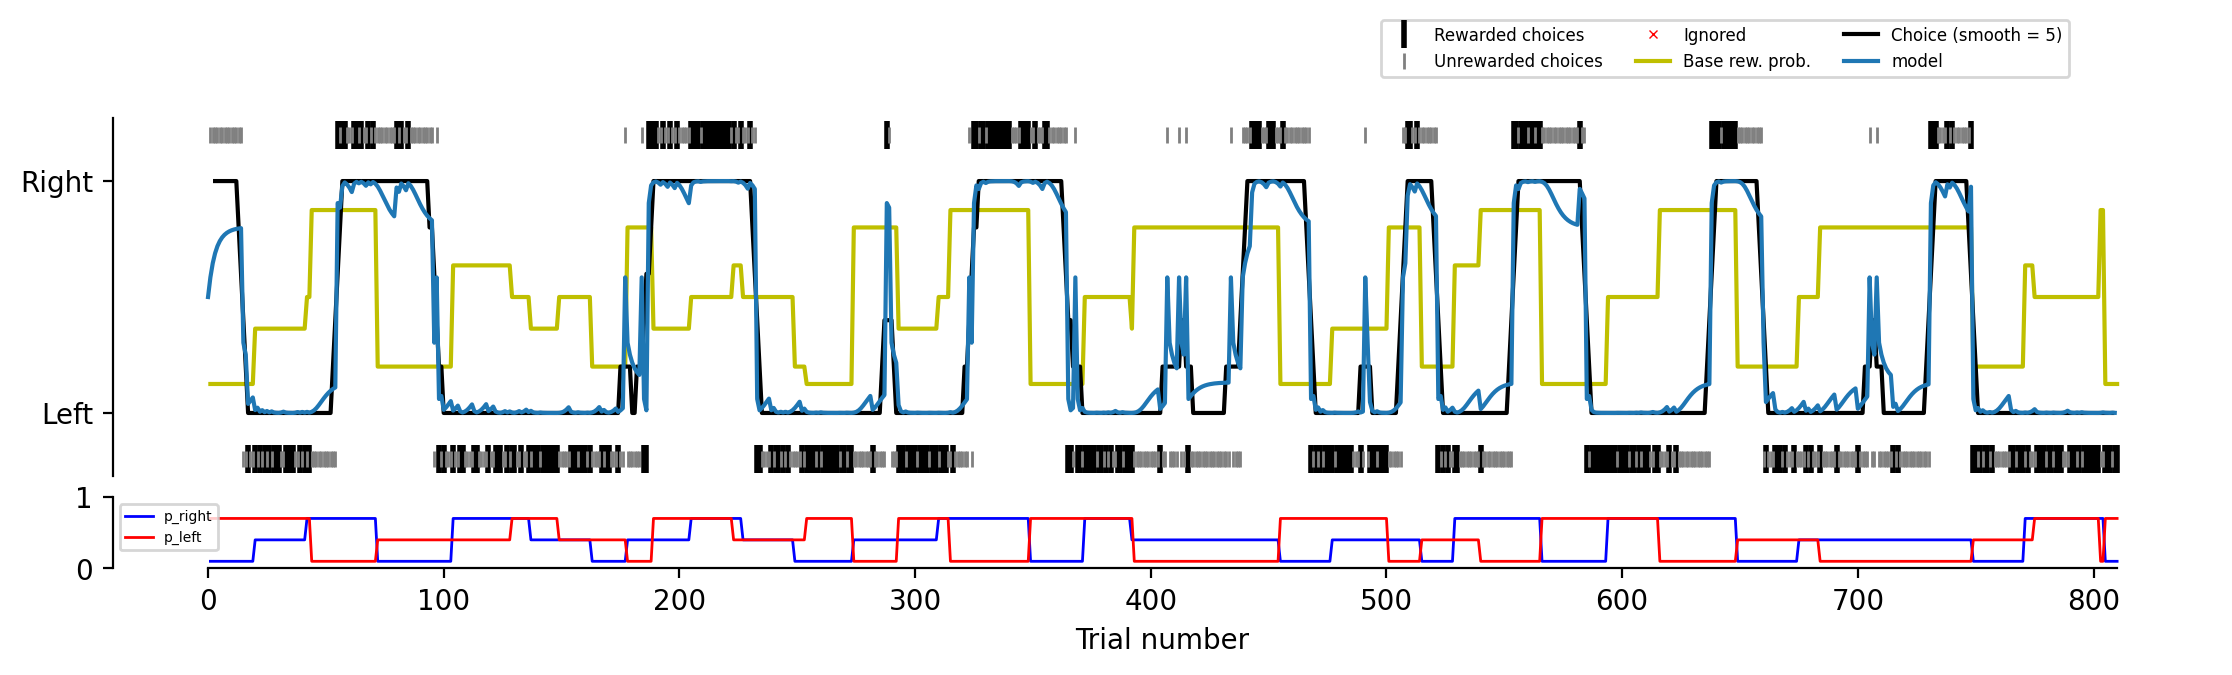

In [2]:
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
from general_utils import find_behavior_sessions

import os

folder_path = '/root/capsule/data/behavior_nwb'  # Replace with your folder path

# List only files (exclude subdirectories)
behavior_sessions = [f for f in os.listdir(folder_path)
         if os.path.isfile(os.path.join(folder_path, f))]



for behavior_session in behavior_sessions[3:4]:
        nwb_data=NWBUtils.read_behavior_nwb(session_name=behavior_session)
        plot_behavior_session(nwb_data=nwb_data,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')

Found behavior NWB: /root/capsule/data/behavior_nwb/behavior_764787_2024-12-11_15-01-15.nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/behavior_764787_2024-12-11_15-01-15.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)


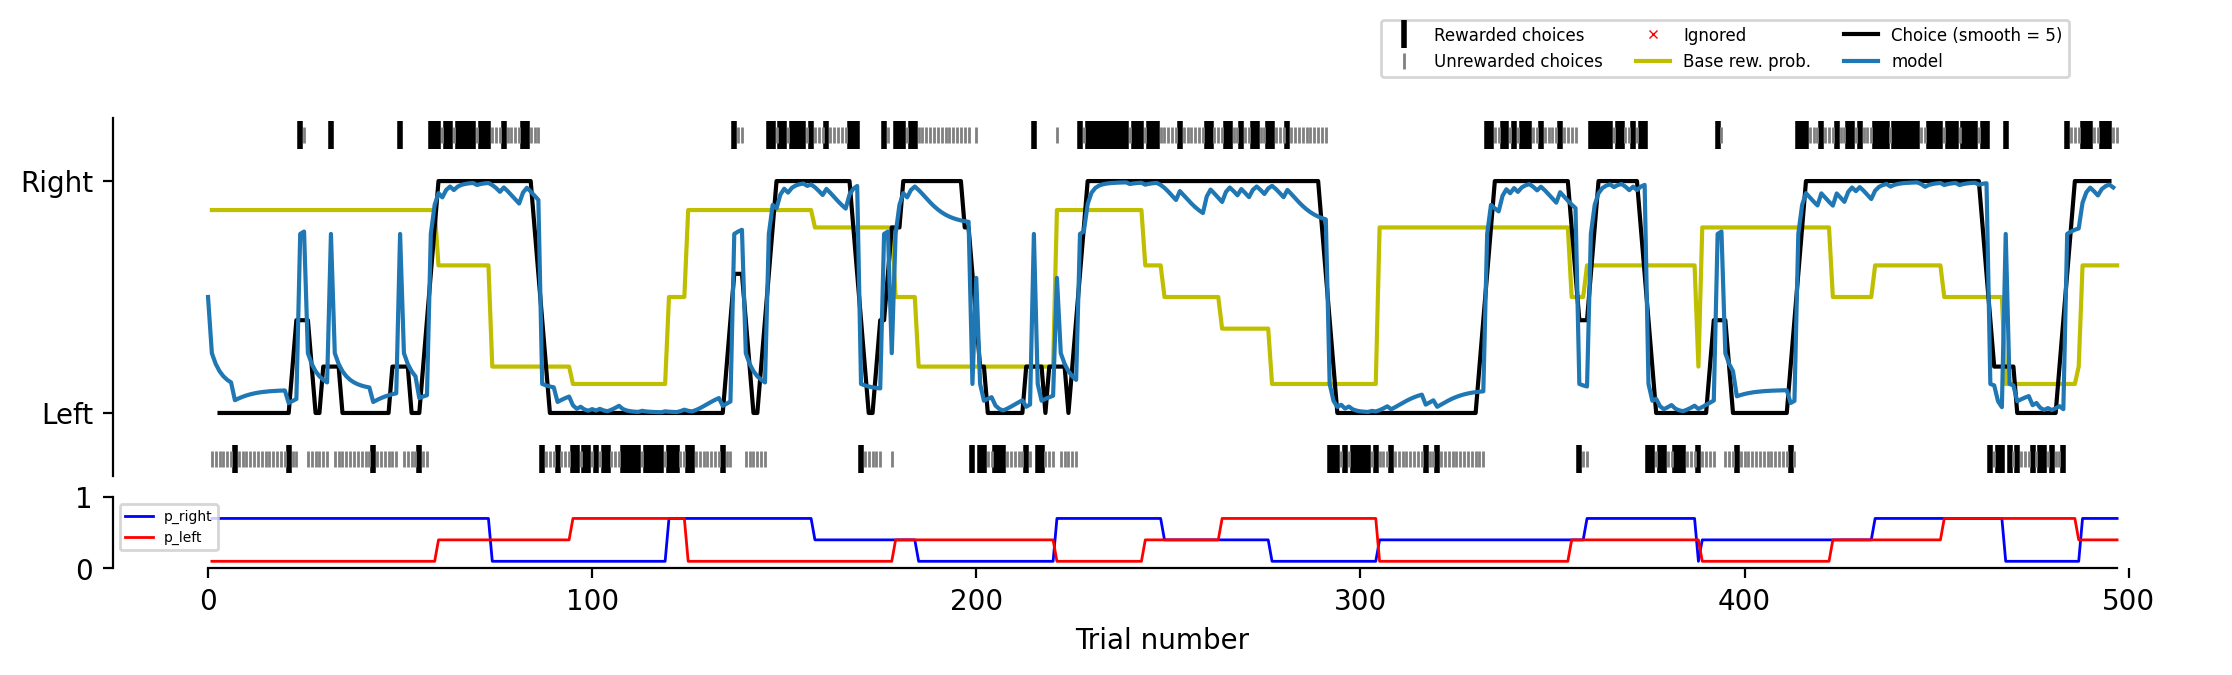

In [3]:
# load one session
import numpy as np
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
from general_utils import find_behavior_sessions

binsize=0.1
sessions = find_ephys_sessions()
session = sessions[2][12]

psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
df = smart_read_csv(f"/root/capsule/scratch/behavior_summary-{session}.csv")
nwb_data=NWBUtils.read_behavior_nwb(session_name=session)
plot_behavior_session(nwb_data=nwb_data,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')



In [26]:
import numpy as np

# --- Extract arrays ---
qvals = np.asarray(df['QLearning_L2F1_CK1_softmax-deltaQ-1'][0], dtype=float)
right_trials = np.asarray(df['right_choice_trials'][0], dtype=int)
left_trials  = np.asarray(df['left_choice_trials'][0],  dtype=int)

# --- Safety: drop NaNs in qvals; keep only valid trial indices ---
n = qvals.shape[0]
valid_idx = np.arange(n)
finite_mask = np.isfinite(qvals)

# Clamp trial lists to the valid range [0, n-1]
left_valid  = np.intersect1d(left_trials,  valid_idx, assume_unique=False)
right_valid = np.intersect1d(right_trials, valid_idx, assume_unique=False)

# Build membership masks (and apply finite q mask)
left_mask  = np.zeros(n, dtype=bool);  left_mask[left_valid]   = True
right_mask = np.zeros(n, dtype=bool);  right_mask[right_valid] = True
left_mask  &= finite_mask
right_mask &= finite_mask

# --- Distances to zero (|Q|) ---
dist = np.abs(qvals)

# Helper to select k indices with smallest distance within a mask
def pick_k_closest(mask, k=50):
    if not np.any(mask):
        return np.array([], dtype=int)
    idx_pool = np.where(mask)[0]                 # candidate indices
    order = np.argsort(dist[idx_pool])           # ascending by |Q|
    return idx_pool[order][:k]

# --- Select trials ---
closest50_left  = pick_k_closest(left_mask,  k=50)
closest50_right = pick_k_closest(right_mask, k=50)

closest50_left_q  = qvals[closest50_left]
closest50_right_q = qvals[closest50_right]

# --- Print results ---
print("50 Left-Choice Trials Closest to Q=0 (sorted by |Q|):")
for t, q in zip(closest50_left, closest50_left_q):
    print(f"Trial {t}: Q = {q:.6f}  |Q| = {abs(q):.6f}")

print("\n50 Right-Choice Trials Closest to Q=0 (sorted by |Q|):")
for t, q in zip(closest50_right, closest50_right_q):
    print(f"Trial {t}: Q = {q:.6f}  |Q| = {abs(q):.6f}")

# Optional: return as numpy arrays for downstream use
closest_left_trials  = closest50_left
closest_right_trials = closest50_right


50 Left-Choice Trials Closest to Q=0 (sorted by |Q|):
Trial 0: Q = 0.000000  |Q| = 0.000000
Trial 1: Q = 0.000000  |Q| = 0.000000
Trial 2: Q = 0.000000  |Q| = 0.000000
Trial 3: Q = 0.000000  |Q| = 0.000000
Trial 4: Q = 0.000000  |Q| = 0.000000
Trial 5: Q = 0.000000  |Q| = 0.000000
Trial 6: Q = 0.000000  |Q| = 0.000000
Trial 42: Q = -0.001994  |Q| = 0.001994
Trial 41: Q = -0.002218  |Q| = 0.002218
Trial 52: Q = 0.002609  |Q| = 0.002609
Trial 142: Q = -0.005625  |Q| = 0.005625
Trial 27: Q = 0.007166  |Q| = 0.007166
Trial 141: Q = 0.010630  |Q| = 0.010630
Trial 28: Q = -0.010654  |Q| = 0.010654
Trial 143: Q = -0.011021  |Q| = 0.011021
Trial 145: Q = -0.011750  |Q| = 0.011750
Trial 144: Q = -0.012180  |Q| = 0.012180
Trial 396: Q = -0.015650  |Q| = 0.015650
Trial 31: Q = -0.016256  |Q| = 0.016256
Trial 29: Q = -0.016260  |Q| = 0.016260
Trial 53: Q = -0.016908  |Q| = 0.016908
Trial 30: Q = -0.017131  |Q| = 0.017131
Trial 484: Q = -0.020790  |Q| = 0.020790
Trial 54: Q = -0.022685  |Q| = 0.022

In [22]:
closest_right_trials

array([ 40, 468, 170, 200,  26,  87, 178, 465, 409, 375, 226, 408, 171,
       357, 464, 175, 198,  88, 174, 172, 197, 173,  90, 358,  89, 196,
       359, 292,  25, 360, 291, 195, 199, 176, 177, 290, 194, 289, 193,
        94, 288, 192,  93, 259, 376, 201, 287, 179, 469, 191])

In [24]:
import numpy as np

# --- Extract arrays ---
qvals = np.asarray(df['QLearning_L2F1_CK1_softmax-deltaQ-1'][0], dtype=float)
right_trials = np.asarray(df['right_choice_trials'][0], dtype=int)
left_trials = np.asarray(df['left_choice_trials'][0], dtype=int)

# --- Find top 50 highest Q trials (right choices) ---
sorted_idx_high = np.argsort(qvals)[::-1]  # descending order
right_masked = [i for i in sorted_idx_high if i in right_trials]
top50_right = np.array(right_masked[:50])
top50_right_qvals = qvals[top50_right]

# --- Find bottom 50 lowest Q trials (left choices) ---
sorted_idx_low = np.argsort(qvals)  # ascending order
left_masked = [i for i in sorted_idx_low if i in left_trials]
bottom50_left = np.array(left_masked[:50])
bottom50_left_qvals = qvals[bottom50_left]

# --- Print results ---
print("Top 50 Right-Choice Trials (High Q):")
for t, q in zip(top50_right, top50_right_qvals):
    print(f"Trial {t}: Q = {q:.4f}")

print("\nBottom 50 Left-Choice Trials (Low Q):")
for t, q in zip(bottom50_left, bottom50_left_qvals):
    print(f"Trial {t}: Q = {q:.4f}")



Top 50 Right-Choice Trials (High Q):
Trial 239: Q = 0.9651
Trial 445: Q = 0.9634
Trial 238: Q = 0.9537
Trial 444: Q = 0.9514
Trial 460: Q = 0.9399
Trial 243: Q = 0.9372
Trial 443: Q = 0.9355
Trial 247: Q = 0.9266
Trial 451: Q = 0.9203
Trial 455: Q = 0.9203
Trial 459: Q = 0.9202
Trial 73: Q = 0.9169
Trial 242: Q = 0.9167
Trial 442: Q = 0.9145
Trial 69: Q = 0.9114
Trial 463: Q = 0.9040
Trial 246: Q = 0.9027
Trial 450: Q = 0.8943
Trial 454: Q = 0.8942
Trial 458: Q = 0.8942
Trial 72: Q = 0.8897
Trial 241: Q = 0.8895
Trial 441: Q = 0.8866
Trial 462: Q = 0.8727
Trial 245: Q = 0.8709
Trial 449: Q = 0.8598
Trial 453: Q = 0.8597
Trial 457: Q = 0.8596
Trial 71: Q = 0.8537
Trial 240: Q = 0.8534
Trial 446: Q = 0.8519
Trial 440: Q = 0.8495
Trial 368: Q = 0.8441
Trial 437: Q = 0.8314
Trial 461: Q = 0.8311
Trial 244: Q = 0.8287
Trial 157: Q = 0.8210
Trial 365: Q = 0.8200
Trial 248: Q = 0.8194
Trial 448: Q = 0.8140
Trial 452: Q = 0.8138
Trial 456: Q = 0.8138
Trial 74: Q = 0.8108
Trial 70: Q = 0.8059
T

In [29]:
bottom50_left=closest_left_trials
top50_right=closest_right_trials

In [30]:
bottom50_left

array([  0,   1,   2,   3,   4,   5,   6,  42,  41,  52, 142,  27, 141,
        28, 143, 145, 144, 396,  31,  29,  53,  30, 484,  54, 395, 397,
       215, 140,  19, 411,  51,  18, 410,  17,  16, 137, 393,  15, 225,
       407,  33,  14, 224, 406, 485, 332, 223,  13, 405,  49])

In [32]:
import numpy as np
import xarray as xr

# --- Config ---
time_window = (-2.0, 0)  # <-- modify this as needed

# --- Grab dataset pieces ---
da_go = psth_da['psth_go_cue']                       # (unit, trial_go_cue, time)
trial_ids_go = psth_da['trial_index_go_cue'].values  # (trial_go_cue,)

# --- Helper: select by trial IDs robustly ---
def select_trials_by_id(da, all_ids, wanted_ids):
    mask = np.isin(all_ids, np.asarray(wanted_ids, dtype=int))
    missing = np.setdiff1d(wanted_ids, all_ids)
    if missing.size > 0:
        print(f"[warn] {missing.size} requested trial IDs not in dataset; ignoring:", missing)
    return da.isel(trial_go_cue=mask)

# --- Select PSTHs for the two groups ---
da_top_right = select_trials_by_id(da_go, trial_ids_go, top50_right)
da_low_left  = select_trials_by_id(da_go, trial_ids_go, bottom50_left)

# --- Restrict to desired time window ---
time = psth_da['time']
time_mask = (time >= time_window[0]) & (time <= time_window[1])
da_top_right = da_top_right.sel(time=time_mask)
da_low_left  = da_low_left.sel(time=time_mask)

# --- Average across trials (keep unit × time) ---
mean_top_right = da_top_right.mean(dim='trial_go_cue')
mean_low_left  = da_low_left.mean(dim='trial_go_cue')

# --- Convert to numpy arrays ---
time_np = mean_top_right['time'].values
mean_top_right_np = mean_top_right.values
mean_low_left_np  = mean_low_left.values

print("Selected time window:", time_window)
print("mean_top_right shape:", mean_top_right_np.shape)
print("mean_low_left  shape:", mean_low_left_np.shape)


Selected time window: (-2.0, 0)
mean_top_right shape: (530, 20)
mean_low_left  shape: (530, 20)


[Epoch 1/5] LEFT (teacher forcing)
  mean step-MSE (z) left:  1.304061
[Epoch 1/5] RIGHT (teacher forcing)
  mean step-MSE (z) right: 1.525885
[Epoch 2/5] LEFT (teacher forcing)
  mean step-MSE (z) left:  0.366773
[Epoch 2/5] RIGHT (teacher forcing)
  mean step-MSE (z) right: 0.378178
[Epoch 3/5] LEFT (teacher forcing)
  mean step-MSE (z) left:  0.395526
[Epoch 3/5] RIGHT (teacher forcing)
  mean step-MSE (z) right: 0.202934
[Epoch 4/5] LEFT (teacher forcing)
  mean step-MSE (z) left:  0.214896
[Epoch 4/5] RIGHT (teacher forcing)
  mean step-MSE (z) right: 0.204333
[Epoch 5/5] LEFT (teacher forcing)
  mean step-MSE (z) left:  0.212855
[Epoch 5/5] RIGHT (teacher forcing)
  mean step-MSE (z) right: 0.187658
Evaluate LEFT...
Evaluate RIGHT...
MSE (z, mean over time) LEFT : 0.523201
MSE (z, mean over time) RIGHT: 0.583395


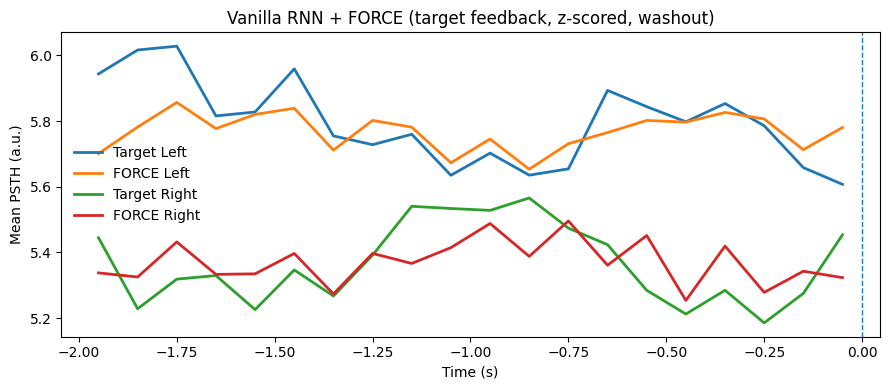

Median R^2 (Left):  0.254
Median R^2 (Right): 0.195


In [33]:
# -*- coding: utf-8 -*-
"""
Vanilla RNN (tanh) + FORCE with target-feedback (teacher forcing), z-scored targets,
washout, and cooler dynamics. Trains to reproduce mean_low_left_np and
mean_top_right_np; recurrent units == number of units (rows).
"""

import numpy as np
import matplotlib.pyplot as plt

# --- Expect in memory ---
# mean_low_left_np:  (n_units, T)
# mean_top_right_np: (n_units, T)
# time_np:           (T,)

n_units, T = mean_low_left_np.shape
assert mean_top_right_np.shape == (n_units, T)
assert time_np.shape[0] == T

# -----------------------------
# Hyperparameters (safer defaults)
# -----------------------------
seed = 7
rng = np.random.default_rng(seed)

n_rec = n_units      # recurrent size = number of units
D     = n_units      # outputs
n_in  = 3            # [bias, random_noise, context_bit]

dt   = float(np.mean(np.diff(time_np)))  # data step
tau  = 0.080                             # slower internal time constant
g    = 1.2                               # cooler recurrent gain
fb_scale  = 0.2                          # weaker output feedback
noise_std = 0.2                          # smaller random drive
alpha     = 10.0                         # stronger RLS regularization
epochs    = 5
washout_s = 0.3                          # seconds to wash out each pass
washout   = int(max(1, round(washout_s / dt)))

# Teacher forcing: in training feedback is y_fb = beta*target + (1-beta)*pred
beta_train = 1.0     # 1.0 = pure target feedback; 0.0 = pure prediction
beta_eval  = 0.0     # at eval use only prediction

report_every = max(1, T // 4)

# -----------------------------
# Prepare targets (T, D) and z-score per unit/channel
# -----------------------------
Y_left  = mean_low_left_np.T        # (T, D)
Y_right = mean_top_right_np.T       # (T, D)

pool = np.vstack([Y_left, Y_right])            # (2T, D)
mu = np.mean(pool, axis=0, keepdims=True)      # (1, D)
sd = np.std (pool, axis=0, keepdims=True) + 1e-8

Y_left_z  = (Y_left  - mu) / sd
Y_right_z = (Y_right - mu) / sd

# -----------------------------
# Initialize weights
# -----------------------------
scale = g / np.sqrt(n_rec)
W_rec = scale * rng.standard_normal((n_rec, n_rec))
W_in  = 0.5 * rng.standard_normal((n_rec, n_in))
W_fb  = (fb_scale / np.sqrt(D)) * rng.standard_normal((n_rec, D))
W_out = np.zeros((n_rec, D))

# RLS accumulator
P = (1.0 / alpha) * np.eye(n_rec)

# -----------------------------
# Utilities
# -----------------------------
def make_inputs(T, noise_std, context_value, rng):
    bias  = np.ones((T, 1))
    noise = rng.normal(0.0, noise_std, size=(T, 1))
    ctx   = np.full((T, 1), float(context_value))
    return np.concatenate([bias, noise, ctx], axis=1)  # (T, 3)

def run_force(Y_target, context_value, train=True, beta=1.0):
    """
    One pass with optional learning.
    Y_target: (T, D), already z-scored
    beta: mix for feedback: y_fb = beta*target + (1-beta)*pred
    Returns Y_pred (T, D), mse_per_timestep (T,)
    """
    x = np.zeros(n_rec)
    y = np.zeros(D)
    Y_pred = np.zeros_like(Y_target)
    mse_seq = np.zeros(T)

    X = make_inputs(T, noise_std, context_value, rng)

    for t in range(T):
        # feedback signal
        y_fb = beta * Y_target[t] + (1.0 - beta) * y

        # reservoir update
        r = np.tanh(W_rec @ x + W_in @ X[t] + W_fb @ y_fb)
        x = x + (dt / tau) * (-x + r)

        # readout
        y = x @ W_out
        Y_pred[t] = y

        # error
        e = y - Y_target[t]
        mse_seq[t] = np.mean(e**2)

        # only learn after washout period
        if train and (t >= washout):
            Px = P @ x
            denom = 1.0 + x @ Px
            k = Px / denom
            W_out[:] = W_out - np.outer(k, e)
            P[:] = P - np.outer(k, Px)

        if (t % report_every == 0) and train:
            pass  # keep quiet; set a print if you want

    return Y_pred, mse_seq

# -----------------------------
# Training: alternate left/right
# -----------------------------
for ep in range(1, epochs + 1):
    print(f"[Epoch {ep}/{epochs}] LEFT (teacher forcing)")
    _, mseL = run_force(Y_left_z,  context_value=0.0, train=True,  beta=beta_train)
    print(f"  mean step-MSE (z) left:  {mseL.mean():.6f}")
    print(f"[Epoch {ep}/{epochs}] RIGHT (teacher forcing)")
    _, mseR = run_force(Y_right_z, context_value=1.0, train=True,  beta=beta_train)
    print(f"  mean step-MSE (z) right: {mseR.mean():.6f}")

# -----------------------------
# Evaluation (no learning, predictive feedback)
# -----------------------------
print("Evaluate LEFT...")
Y_left_hat_z,  mseL = run_force(Y_left_z,  context_value=0.0, train=False, beta=beta_eval)
print("Evaluate RIGHT...")
Y_right_hat_z, mseR = run_force(Y_right_z, context_value=1.0, train=False, beta=beta_eval)

# Un-normalize back to original scale
Y_left_hat  = Y_left_hat_z  * sd + mu
Y_right_hat = Y_right_hat_z * sd + mu

pred_left_np  = Y_left_hat.T
pred_right_np = Y_right_hat.T

# -----------------------------
# Diagnostics & plots
# -----------------------------
def pop_mean(a):  # (n_units, T) -> (T,)
    return a.mean(axis=0)

print(f"MSE (z, mean over time) LEFT : {mseL.mean():.6f}")
print(f"MSE (z, mean over time) RIGHT: {mseR.mean():.6f}")

plt.figure(figsize=(9, 4))
plt.plot(time_np, pop_mean(mean_low_left_np),  label='Target Left',  linewidth=2)
plt.plot(time_np, pop_mean(pred_left_np),      label='FORCE Left',   linewidth=2)
plt.plot(time_np, pop_mean(mean_top_right_np), label='Target Right', linewidth=2)
plt.plot(time_np, pop_mean(pred_right_np),     label='FORCE Right',  linewidth=2)
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Mean PSTH (a.u.)')
plt.title('Vanilla RNN + FORCE (target feedback, z-scored, washout)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Per-unit R^2 (on original scale)
def r2_unitwise(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2, axis=1)
    ss_tot = np.sum((y_true - y_true.mean(axis=1, keepdims=True))**2, axis=1) + 1e-12
    return 1.0 - ss_res / ss_tot

r2_left  = r2_unitwise(mean_low_left_np,  pred_left_np)
r2_right = r2_unitwise(mean_top_right_np, pred_right_np)
print(f"Median R^2 (Left):  {np.median(r2_left):.3f}")
print(f"Median R^2 (Right): {np.median(r2_right):.3f}")


Neuron 0: R² Left = 0.338, R² Right = 0.024


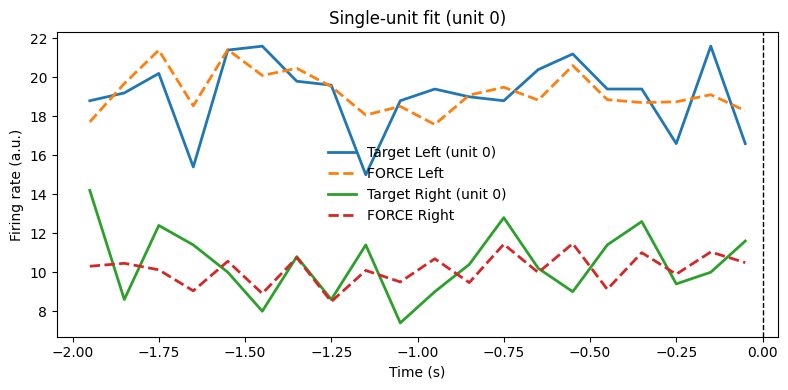

In [34]:
# --- Visualize fit for one neuron ---
import matplotlib.pyplot as plt

# Choose neuron index (0-based)
unit_idx = 0   # change this to any neuron index you want

# Extract single-unit traces
y_true_left  = mean_low_left_np[unit_idx, :]
y_pred_left  = pred_left_np[unit_idx, :]
y_true_right = mean_top_right_np[unit_idx, :]
y_pred_right = pred_right_np[unit_idx, :]

# Compute R² values
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2) + 1e-12
    return 1 - ss_res / ss_tot

r2_left  = r2(y_true_left,  y_pred_left)
r2_right = r2(y_true_right, y_pred_right)
print(f"Neuron {unit_idx}: R² Left = {r2_left:.3f}, R² Right = {r2_right:.3f}")

# Plot
plt.figure(figsize=(8,4))
plt.plot(time_np, y_true_left,  label=f'Target Left (unit {unit_idx})',  linewidth=2)
plt.plot(time_np, y_pred_left,  label=f'FORCE Left',  linestyle='--', linewidth=2)
plt.plot(time_np, y_true_right, label=f'Target Right (unit {unit_idx})', linewidth=2)
plt.plot(time_np, y_pred_right, label=f'FORCE Right', linestyle='--', linewidth=2)
plt.axvline(0, linestyle='--', color='k', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Firing rate (a.u.)')
plt.title(f'Single-unit fit (unit {unit_idx})')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


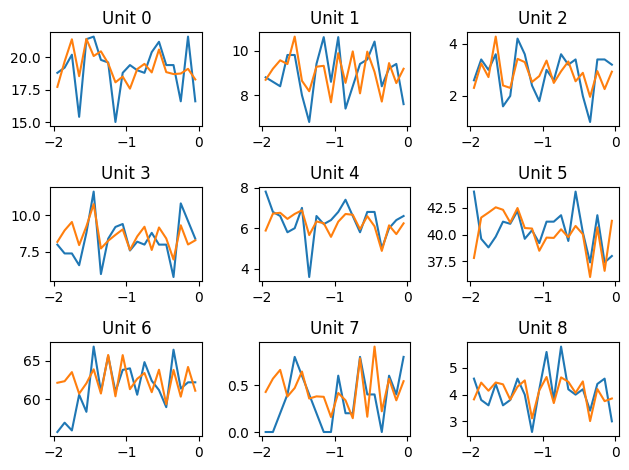

In [35]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(time_np, mean_low_left_np[i], label='Target')
    plt.plot(time_np, pred_left_np[i], label='FORCE')
    plt.title(f'Unit {i}')
plt.tight_layout()
plt.show()


In [11]:
# --- Reverse engineering: fixed points + stability (PHYSICAL SCALE) ---

import numpy as np

# ====== Config ======
max_iter   = 5000          # iterations for FP solver
tol_fp     = 1e-8          # convergence tolerance on ||x_{k+1}-x_k||
n_inits    = 200           # random initializations per context
dedup_eps  = 1e-4          # de-dup distance in state space
eta        = 1.0           # damping in FP iteration (0<eta<=1; try 0.3–0.7 if hard to converge)
ctx_values = [0.0, 1.0]    # left/right contexts

# ====== Model shapes and combined map ======
n_rec = W_rec.shape[0]
D     = W_out.shape[1]
M     = W_rec + W_fb @ W_out.T  # effective recurrent+feedback map

# ====== Helper: input vector (bias, noise=0 for FP, context) ======
def make_u(ctx):
    return np.array([1.0, 0.0, float(ctx)])  # (3,)

# ====== Convert z-scored outputs -> physical PSTH scale ======
# If you trained with z-scoring, mu/sd should be available from training.
# If not, we gracefully fall back to identity transform.
def _get_mu_sd():
    if 'mu' in globals() and 'sd' in globals():
        mu_vec = np.squeeze(np.asarray(mu))  # (D,) or (1,D)
        sd_vec = np.squeeze(np.asarray(sd))  # (D,) or (1,D)
        if mu_vec.shape[0] == D and sd_vec.shape[0] == D:
            return mu_vec, sd_vec
    # fallback: no scaling
    return np.zeros(D), np.ones(D)

_mu_vec, _sd_vec = _get_mu_sd()

def to_phys(y_z):
    """
    Convert output from z space to original PSTH scale.
    Accepts (D,), (T,D) or (D,T); returns same orientation.
    """
    y = np.asarray(y_z)
    muv, sdv = _mu_vec, _sd_vec
    if y.ndim == 1:                   # (D,)
        return y * sdv + muv
    elif y.ndim == 2:
        if y.shape[0] == D:           # (D, T)
            return (y.T * sdv + muv).T
        elif y.shape[1] == D:         # (T, D)
            return y * sdv + muv
        else:
            raise ValueError("to_phys: unexpected 2D shape for output.")
    else:
        raise ValueError("to_phys: only 1D/2D arrays supported.")

# ====== Fixed-point solver (fixed-point iteration with optional damping) ======
def find_fixed_points_for_context(ctx, rng=np.random.default_rng(0)):
    u = make_u(ctx)
    U = W_in @ u
    fixed_pts = []

    for _ in range(n_inits):
        x = rng.uniform(-0.5, 0.5, size=n_rec)
        for _ in range(max_iter):
            h = M @ x + U
            x_next_naive = np.tanh(h)
            x_next = (1.0 - eta) * x + eta * x_next_naive  # damping
            if np.max(np.abs(x_next - x)) < tol_fp:
                x = x_next
                break
            x = x_next

        # de-duplicate by Euclidean distance
        if len(fixed_pts) == 0 or all(np.linalg.norm(x - xp) > dedup_eps for xp in fixed_pts):
            fixed_pts.append(x)

    if len(fixed_pts) == 0:
        return np.zeros((0, n_rec))
    return np.array(fixed_pts)

# ====== Stability via Jacobian (continuous-time) ======
def jacobian_at_x(x, ctx):
    u = make_u(ctx)
    U = W_in @ u
    h = M @ x + U
    rprime = 1.0 - np.tanh(h)**2  # dr/dh elementwise
    # Continuous-time Jacobian of dx/dt = (-x + tanh(Mx+U))/tau
    J = (-np.eye(n_rec) + (rprime[:, None] * M)) / tau
    return J

def classify_fp(x, ctx):
    J = jacobian_at_x(x, ctx)
    eigvals = np.linalg.eigvals(J)
    stable_ct = np.all(np.real(eigvals) < 0.0)
    # Optional discrete-time check for Euler step: A = I + J*dt
    if 'dt' in globals():
        A = np.eye(n_rec) + dt * J
        rho = np.max(np.abs(np.linalg.eigvals(A)))
    else:
        rho = np.nan
    return eigvals, stable_ct, rho

# ====== Run search ======
fp_dict = {}
for ctx in ctx_values:
    fps = find_fixed_points_for_context(ctx)
    info = []
    for k in range(fps.shape[0]):
        lam, is_stable_ct, rhoA = classify_fp(fps[k], ctx)
        info.append({
            "x": fps[k],
            "eigvals_ct": lam,
            "stable_ct": bool(is_stable_ct),
            "rho_discrete": float(rhoA),
            "context": ctx,
        })
    fp_dict[ctx] = info
    n_stable = sum(int(it['stable_ct']) for it in info)
    print(f"Context {ctx}: found {len(info)} unique fixed points ({n_stable} stable by CT criterion).")

# ====== Phys-scale output from state and reporting ======
def output_from_state(x):
    y_z = x @ W_out        # (D,) in z space
    return to_phys(y_z)    # (D,) in original PSTH scale

for ctx in ctx_values:
    items = fp_dict.get(ctx, [])
    if not items:
        continue
    print(f"\n=== Context {ctx} fixed points ===")
    for i, it in enumerate(items):
        y_phys = output_from_state(it["x"])  # (D,)
        eig = it["eigvals_ct"]
        max_real = np.max(np.real(eig))
        print(
            f"FP #{i:02d} | stable_ct={it['stable_ct']} | "
            f"max Re(λ)={max_real:.4f} | ρ(I+J·dt)={it['rho_discrete']:.4f} | "
            f"||x||={np.linalg.norm(it['x']):.4f} | ||y_phys||={np.linalg.norm(y_phys):.4f}"
        )
        # If coding direction is available, also print projection
        if 'cd' in globals():
            proj_val = cd @ y_phys
            print(f"    CD projection (phys): {proj_val:.6f}")

# ====== Convenience: pick one stable FP per context (if any) ======
def pick_stable_fp(ctx):
    cands = [it for it in fp_dict.get(ctx, []) if it["stable_ct"]]
    return cands[0]["x"] if cands else None

fp_left  = pick_stable_fp(0.0)
fp_right = pick_stable_fp(1.0)


Context 0.0: found 1 unique fixed points (1 stable by CT criterion).
Context 1.0: found 1 unique fixed points (1 stable by CT criterion).

=== Context 0.0 fixed points ===
FP #00 | stable_ct=True | max Re(λ)=-1.3068 | ρ(I+J·dt)=1.2985 | ||x||=13.8181 | ||y_phys||=248.9747

=== Context 1.0 fixed points ===
FP #00 | stable_ct=True | max Re(λ)=-2.5474 | ρ(I+J·dt)=1.2596 | ||x||=14.6807 | ||y_phys||=208.2560


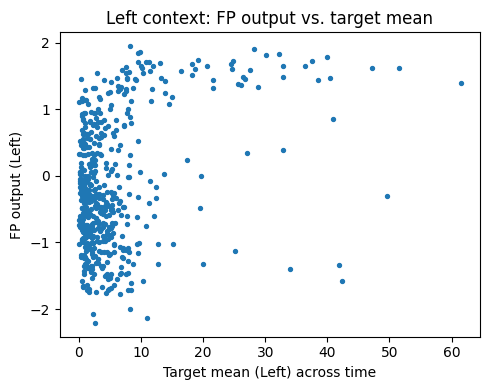

In [12]:
import matplotlib.pyplot as plt

if fp_left is not None:
    y_fp_left = fp_left @ W_out              # (n_units,)
    y_mean_left = mean_low_left_np.mean(axis=1)  # per-unit mean over time
    plt.figure(figsize=(5,4))
    plt.scatter(y_mean_left, y_fp_left, s=8)
    plt.xlabel('Target mean (Left) across time')
    plt.ylabel('FP output (Left)')
    plt.title('Left context: FP output vs. target mean')
    plt.tight_layout(); plt.show()


In [13]:
def spectral_radius_discrete(x, ctx):
    J = jacobian_at_x(x, ctx)        # continuous
    A = np.eye(n_rec) + dt * J       # Euler step linearization
    return np.max(np.abs(np.linalg.eigvals(A)))

if fp_left is not None:
    rho = spectral_radius_discrete(fp_left, 0.0)
    print("Left FP discrete-time spectral radius:", rho)


Left FP discrete-time spectral radius: 1.2984696809184613


In [14]:
def simulate(context_value, T_steps=500, eps=1e-3):
    x = pick_stable_fp(context_value).copy() + eps*np.random.randn(n_rec)
    y = x @ W_out
    traj = np.zeros((T_steps, n_rec))
    for t in range(T_steps):
        y_fb = y  # predictive feedback
        r = np.tanh(W_rec @ x + W_in @ make_u(context_value) + W_fb @ y_fb)
        x = x + (dt / tau) * (-x + r)
        y = x @ W_out
        traj[t] = x
    return traj

if fp_right is not None:
    traj = simulate(1.0, T_steps=200)
    print("Traj norm first/last:", np.linalg.norm(traj[0]), np.linalg.norm(traj[-1]))


Traj norm first/last: 14.681216303521524 23.222356042789862


Coding-direction computed on window (-0.5, 0.5) | norm = 0.999999999999989


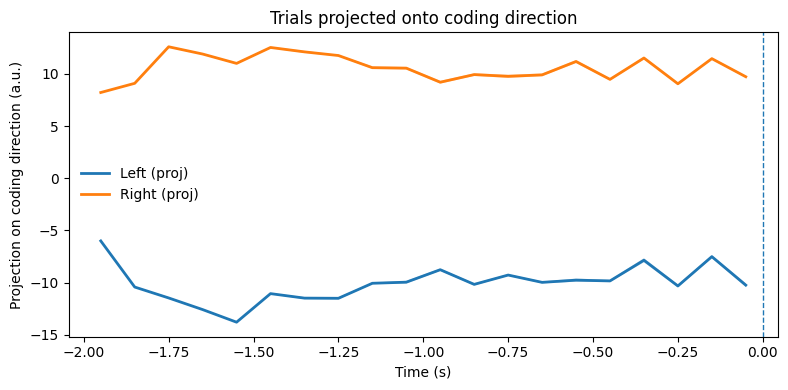

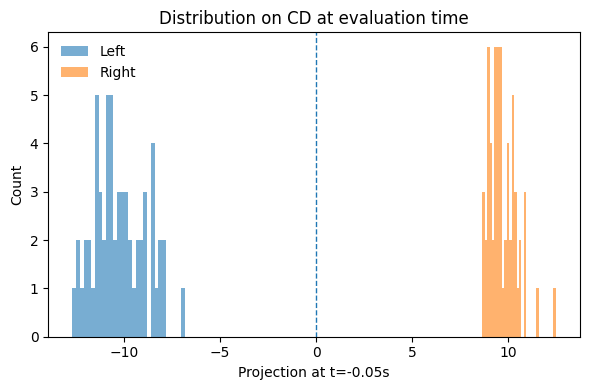

CD classification accuracy at t=-0.05s: 0.0%


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1) Coding direction (right - left)
# -------------------------------
# Choose a time window to define the CD (change as you like)
cd_window = (-0.5, 0.5)   # seconds around the go cue
mask = (time_np >= cd_window[0]) & (time_np <= cd_window[1])

Y0 = mean_low_left_np[:, mask]    # (units, Twin)
Y1 = mean_top_right_np[:, mask]   # (units, Twin)

m0 = Y0.mean(axis=1)              # per-unit mean in window (left)
m1 = Y1.mean(axis=1)              # per-unit mean in window (right)

# Option A (default): difference-of-means coding direction
cd = (m1 - m0).astype(float)

# Option B (uncomment to use Fisher-LDA style; maximizes class separation)
# S0 = np.cov(Y0)  # pooled covariance can be noisy for many units; add ridge
# S1 = np.cov(Y1)
# Sp = 0.5 * (S0 + S1) + 1e-3 * np.eye(S0.shape[0])
# cd = np.linalg.solve(Sp, (m1 - m0))

# Normalize CD to unit length
cd_norm = np.linalg.norm(cd) + 1e-12
cd /= cd_norm   # (units,)

print("Coding-direction computed on window", cd_window,
      "| norm =", np.linalg.norm(cd))

# Helper: project population activity Y (units × T) onto CD -> (T,)
def project_cd(Y_units_T):
    return cd @ Y_units_T   # (T,)

# -------------------------------
# 2) Simulate trials from the trained RNN
# -------------------------------
# Inputs are [bias, random_noise, context_bit]
def make_u_step(context_value, noise_std_sim):
    return np.array([1.0, np.random.normal(0.0, noise_std_sim), float(context_value)])

def simulate_trials(context_value, n_trials=50, noise_std_sim=0.3, washout_steps=0):
    """
    Simulate n_trials trajectories with predictive feedback (no further learning).
    Returns array of shape (n_trials, units, T).
    """
    D = W_out.shape[1]      # number of output channels = units
    n_rec = W_rec.shape[0]
    M = W_rec + W_fb @ W_out.T

    trials = np.zeros((n_trials, D, len(time_np)))
    for k in range(n_trials):
        x = np.zeros(n_rec)
        y = np.zeros(D)
        for t in range(len(time_np)):
            u = make_u_step(context_value, noise_std_sim)
            # predictive feedback (no teacher forcing)
            r = np.tanh(M @ x + W_in @ u + W_fb @ y)
            x = x + (dt / tau) * (-x + r)
            y = x @ W_out
            trials[k, :, t] = y
    # optional washout (drop first few steps if desired)
    if washout_steps > 0:
        trials = trials[:, :, washout_steps:]
    return trials

# Simulate some trials
n_sim = 60
trials_left  = simulate_trials(context_value=0.0, n_trials=n_sim, noise_std_sim=0.3, washout_steps=0)  # (n, units, T)
trials_right = simulate_trials(context_value=1.0, n_trials=n_sim, noise_std_sim=0.3, washout_steps=0)

# -------------------------------
# 3) Project onto CD and visualize
# -------------------------------
# Projections have shape (n_trials, T)
proj_left  = np.tensordot(trials_left,  cd, axes=([1],[0]))
proj_right = np.tensordot(trials_right, cd, axes=([1],[0]))

# Mean ± SEM across trials
def mean_sem(a, axis=0):
    m = a.mean(axis=axis)
    s = a.std(axis=axis) / np.sqrt(a.shape[axis])
    return m, s

mL, sL = mean_sem(proj_left,  axis=0)
mR, sR = mean_sem(proj_right, axis=0)

# --- Plot time courses on CD ---
plt.figure(figsize=(8,4))
plt.plot(time_np, mL, label='Left (proj)', linewidth=2)
plt.fill_between(time_np, mL - sL, mL + sL, alpha=0.3)
plt.plot(time_np, mR, label='Right (proj)', linewidth=2)
plt.fill_between(time_np, mR - sR, mR + sR, alpha=0.3)
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Projection on coding direction (a.u.)')
plt.title('Trials projected onto coding direction')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Optional: discrimination snapshot at a specific time (e.g., near decision time) ---
t_eval = 0.0  # seconds
t_idx = int(np.argmin(np.abs(time_np - t_eval)))

plt.figure(figsize=(6,4))
plt.hist(proj_left[:, t_idx],  bins=30, alpha=0.6, label='Left')
plt.hist(proj_right[:, t_idx], bins=30, alpha=0.6, label='Right')
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel(f'Projection at t={time_np[t_idx]:.2f}s')
plt.ylabel('Count')
plt.title('Distribution on CD at evaluation time')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Optional: quick linear readout accuracy from CD at t_eval ---
thresh = 0.5 * (proj_left[:, t_idx].mean() + proj_right[:, t_idx].mean())
yhat_left  = (proj_left[:, t_idx]  > thresh).astype(int)
yhat_right = (proj_right[:, t_idx] > thresh).astype(int)
acc = (yhat_left.mean() + (1 - yhat_right).mean()) / 2.0  # left labeled 0, right labeled 1
print(f"CD classification accuracy at t={time_np[t_idx]:.2f}s: {acc*100:.1f}%")


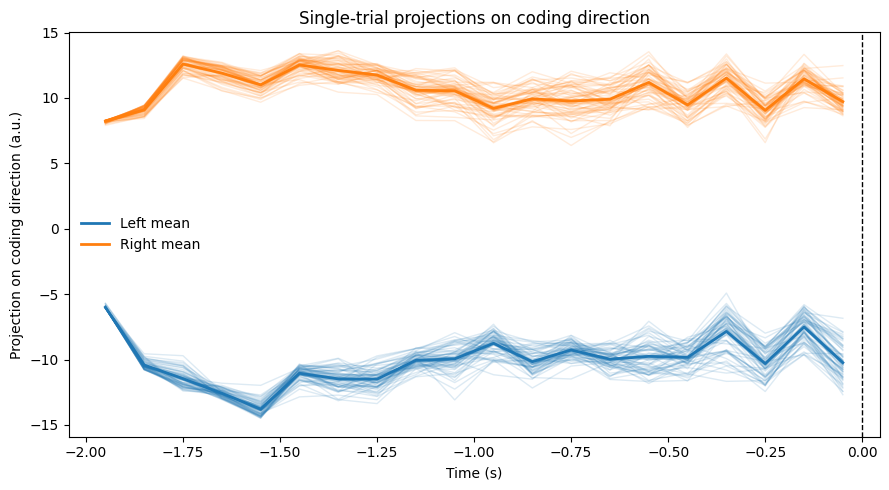

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# === 1) Project single trials onto the coding direction ===
proj_left  = np.tensordot(trials_left,  cd, axes=([1], [0]))   # (n_trials, T)
proj_right = np.tensordot(trials_right, cd, axes=([1], [0]))   # (n_trials, T)

# === 2) Compute mean ± SEM ===
def mean_sem(a, axis=0):
    m = a.mean(axis=axis)
    s = a.std(axis=axis) / np.sqrt(a.shape[axis])
    return m, s

mL, sL = mean_sem(proj_left,  axis=0)
mR, sR = mean_sem(proj_right, axis=0)

# === 3) Plot all single trials + mean ± SEM ===
plt.figure(figsize=(9,5))

# Left-context (label 0) trials
for i in range(proj_left.shape[0]):
    plt.plot(time_np, proj_left[i, :], color='tab:blue', alpha=0.15, linewidth=1)
plt.plot(time_np, mL, color='tab:blue', linewidth=2, label='Left mean')
plt.fill_between(time_np, mL - sL, mL + sL, color='tab:blue', alpha=0.2)

# Right-context (label 1) trials
for i in range(proj_right.shape[0]):
    plt.plot(time_np, proj_right[i, :], color='tab:orange', alpha=0.15, linewidth=1)
plt.plot(time_np, mR, color='tab:orange', linewidth=2, label='Right mean')
plt.fill_between(time_np, mR - sR, mR + sR, color='tab:orange', alpha=0.2)

plt.axvline(0, linestyle='--', color='k', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Projection on coding direction (a.u.)')
plt.title('Single-trial projections on coding direction')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


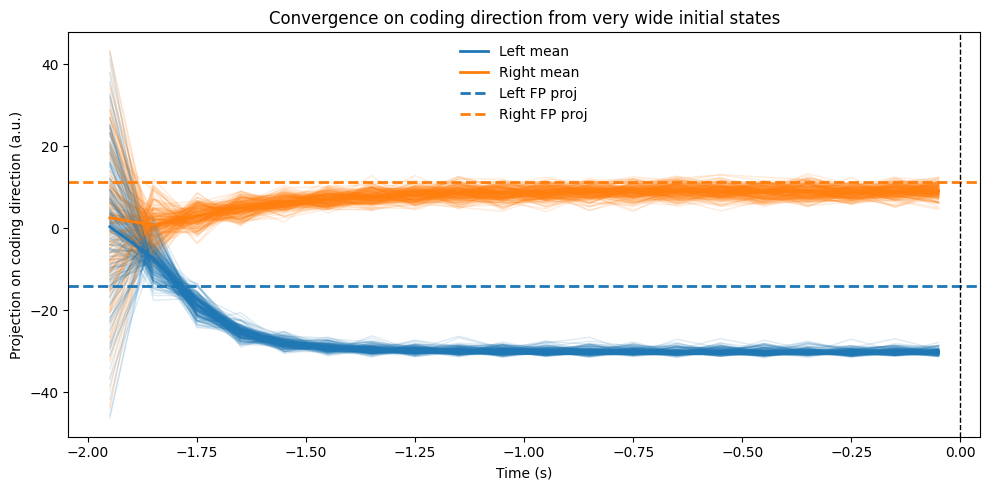

In [18]:
# --- Wide-range convergence visualization on the coding direction ---
import numpy as np
import matplotlib.pyplot as plt

n_rec = W_rec.shape[0]
D = W_out.shape[1]
M = W_rec + W_fb @ W_out.T
rng = np.random.default_rng(123)

# >>> very wide coverage <<<
n_traj = 200
init_mode = "hypercube"   # "sphere" also works
init_radius = 50      # much larger range
noise_std_sim = 0.8       # moderate noise for fluctuations
T_steps = len(time_np)

def sample_initial_states(n_traj, n_rec, mode="hypercube", radius=1.0, rng=None):
    if rng is None: rng = np.random.default_rng()
    if mode == "sphere":
        x0 = rng.normal(0.0, 1.0, size=(n_traj, n_rec))
        x0 /= (np.linalg.norm(x0, axis=1, keepdims=True) + 1e-12)
        x0 *= radius
    elif mode == "hypercube":
        x0 = rng.uniform(low=-radius, high=radius, size=(n_traj, n_rec))
    else:
        raise ValueError("init_mode must be 'sphere' or 'hypercube'")
    return x0

def make_u(ctx, noise_std):
    return np.array([1.0, rng.normal(0.0, noise_std), float(ctx)])

def simulate_with_noise(ctx, x0, T_steps, noise_std):
    x = x0.copy()
    y = x @ W_out
    Y = np.zeros((D, T_steps))
    for t in range(T_steps):
        u = make_u(ctx, noise_std)
        r = np.tanh(M @ x + W_in @ u + W_fb @ y)
        x = x + (dt / tau) * (-x + r)
        y = x @ W_out
        Y[:, t] = y
    return Y

def find_fp(ctx, tol=1e-8, max_iter=5000):
    u = np.array([1.0, 0.0, float(ctx)])
    U = W_in @ u
    x = np.zeros(n_rec)
    for _ in range(max_iter):
        x_next = np.tanh(M @ x + U)
        if np.max(np.abs(x_next - x)) < tol:
            return x_next
        x = x_next
    return x

def project_cd(Y_units_T):
    return cd @ Y_units_T

# wide-range starting points
x0s = sample_initial_states(n_traj, n_rec, mode=init_mode, radius=init_radius, rng=rng)

# compute FP projections for reference
fp_L, fp_R = find_fp(0.0), find_fp(1.0)
y_fp_L_proj = cd @ (fp_L @ W_out)
y_fp_R_proj = cd @ (fp_R @ W_out)

# simulate and project both contexts
proj_L, proj_R = [], []
for i in range(n_traj):
    YL = simulate_with_noise(-4, x0s[i], T_steps, noise_std_sim)
    YR = simulate_with_noise(1.0, x0s[i], T_steps, noise_std_sim)
    proj_L.append(project_cd(YL))
    proj_R.append(project_cd(YR))
proj_L, proj_R = np.stack(proj_L), np.stack(proj_R)

# plotting both contexts together
plt.figure(figsize=(10, 5))
for k in range(n_traj):
    plt.plot(time_np, proj_L[k],  color='tab:blue', alpha=0.15, linewidth=1)
    plt.plot(time_np, proj_R[k],  color='tab:orange', alpha=0.15, linewidth=1)

# overlay means ± SEM
def mean_sem(a):
    m = a.mean(axis=0)
    s = a.std(axis=0) / np.sqrt(a.shape[0])
    return m, s
mL, sL = mean_sem(proj_L)
mR, sR = mean_sem(proj_R)

plt.plot(time_np, mL, color='tab:blue', linewidth=2, label='Left mean')
plt.fill_between(time_np, mL-sL, mL+sL, color='tab:blue', alpha=0.25)
plt.plot(time_np, mR, color='tab:orange', linewidth=2, label='Right mean')
plt.fill_between(time_np, mR-sR, mR+sR, color='tab:orange', alpha=0.25)

# fixed-point projection lines
plt.axhline(y_fp_L_proj, color='tab:blue', linestyle='--', linewidth=2, label='Left FP proj')
plt.axhline(y_fp_R_proj, color='tab:orange', linestyle='--', linewidth=2, label='Right FP proj')
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Projection on coding direction (a.u.)')
plt.title('Convergence on coding direction from very wide initial states')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
